In [14]:
# Setup
import sys
import os

# Path setup
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(BASE_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# LSTM
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Project modules
from src.config import PROCESSED_DIR, REPORTS_DIR

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

# Commodity names in dataset
COMMODITY_COLS = {'corn': 'Corn', 'soybeans': 'Soybeans', 'wheat': 'Wheat'}
COMMODITIES = list(COMMODITY_COLS.keys())

TensorFlow: 2.18.0
GPU disponible: []


## 1. Cargar Dataset

In [15]:
# Load data
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'features_final_modeling.csv'))
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Dataset: {df.shape[0]} observaciones, {df.shape[1]} columnas")
print(f"Período: {df['date'].min()} → {df['date'].max()}")

# Verify data loaded
print(f"\nColumnas spot: {list(COMMODITY_COLS.values())}")
print(f"Muestra primeras 3 filas:")
print(df[['date'] + list(COMMODITY_COLS.values())].head(3))

Dataset: 6731 observaciones, 3187 columnas
Período: 2000-01-03 00:00:00 → 2025-11-10 00:00:00

Columnas spot: ['Corn', 'Soybeans', 'Wheat']
Muestra primeras 3 filas:
        date    Corn  Soybeans  Wheat
0 2000-01-03  377.75    986.75  519.5
1 2000-01-04  377.75    986.75  519.5
2 2000-01-05  377.75    986.75  519.5


In [ ]:
# Create target variables (price at t+7)
h = 7
for commodity in COMMODITIES:
    spot_col = COMMODITY_COLS[commodity]  # e.g., 'Corn'
    target_col = f"{commodity}_target"
    df[target_col] = df[spot_col].shift(-h)

# Remove last h rows (no target)
df = df.iloc[:-h].copy()

print(f"\nDataset con targets: {df.shape[0]} obs")
print(f"Targets creados: {[c for c in df.columns if '_target' in c]}")
print(f"\nPrimeras 3 filas (target vs spot):")
for commodity in COMMODITIES:
    spot_col = COMMODITY_COLS[commodity]
    target_col = f"{commodity}_target"
    print(f"\n{commodity.upper()}:")
    print(f"  Spot (t): {df[spot_col].iloc[0]:.2f}")
    print(f"  Target (t+{h}): {df[target_col].iloc[0]:.2f}")


Dataset con targets: 6724 obs
Targets creados: ['corn_target', 'soybeans_target', 'wheat_target']

Primeras 3 filas (target vs spot):

CORN:
  Spot (t): 377.75
  Target (t+7): 377.75

SOYBEANS:
  Spot (t): 986.75
  Target (t+7): 986.75

WHEAT:
  Spot (t): 519.50
  Target (t+7): 519.50


## 2. Identificar Orden ARIMA

Usamos ACF/PACF para determinar órdenes (p, d, q) óptimos.

In [23]:
def test_stationarity(series, commodity):
    """Test ADF para estacionariedad"""
    result = adfuller(series.dropna())
    print(f"\n{commodity.upper()} - Test ADF:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Crítico (5%): {result[4]['5%']:.4f}")
    print(f"  Conclusión: {'ESTACIONARIA' if result[1] < 0.05 else 'NO ESTACIONARIA'}")
    return result[1] < 0.05

# Test each commodity
for commodity in COMMODITIES:
    target_col = f"{commodity}_target"
    is_stationary = test_stationarity(df[target_col], commodity)


CORN - Test ADF:
  ADF Statistic: -2.2228
  p-value: 0.1981
  Crítico (5%): -2.8620
  Conclusión: NO ESTACIONARIA

SOYBEANS - Test ADF:
  ADF Statistic: -2.2549
  p-value: 0.1869
  Crítico (5%): -2.8620
  Conclusión: NO ESTACIONARIA

SOYBEANS - Test ADF:
  ADF Statistic: -2.2549
  p-value: 0.1869
  Crítico (5%): -2.8620
  Conclusión: NO ESTACIONARIA

WHEAT - Test ADF:
  ADF Statistic: -2.8843
  p-value: 0.0472
  Crítico (5%): -2.8620
  Conclusión: ESTACIONARIA

WHEAT - Test ADF:
  ADF Statistic: -2.8843
  p-value: 0.0472
  Crítico (5%): -2.8620
  Conclusión: ESTACIONARIA


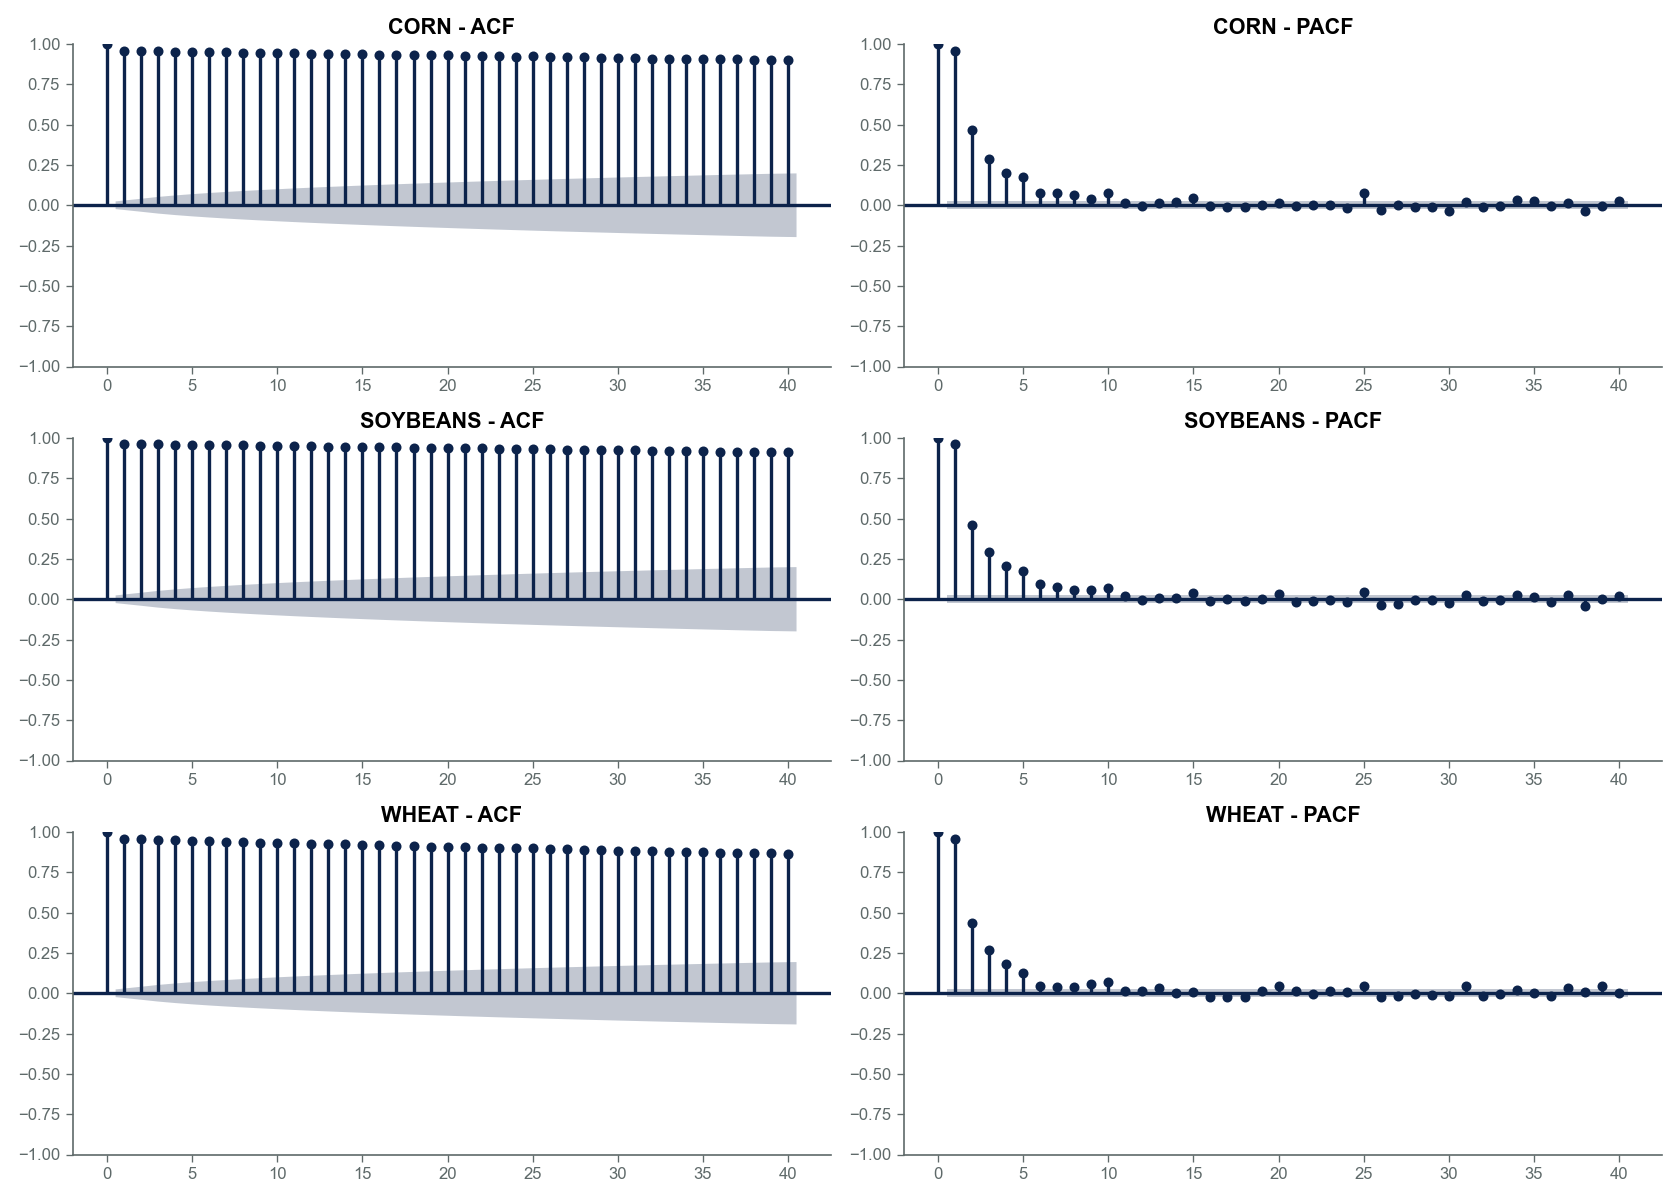

✓ Gráfico guardado: arima_acf_pacf.png


In [18]:
# Plot ACF/PACF para identificar órdenes
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, commodity in enumerate(COMMODITIES):
    target_col = f"{commodity}_target"
    series = df[target_col].dropna()
    
    # ACF
    plot_acf(series, lags=40, ax=axes[i, 0], title=f"{commodity.upper()} - ACF")
    
    # PACF
    plot_pacf(series, lags=40, ax=axes[i, 1], title=f"{commodity.upper()} - PACF")

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'figures', 'arima_acf_pacf.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: arima_acf_pacf.png")

## 3. Entrenar ARIMA y Obtener Residuos

Probamos diferentes órdenes ARIMA(p,d,q) y seleccionamos el mejor por AIC.

In [24]:
def find_best_arima(series, max_p=5, max_d=2, max_q=5):
    """Grid search para encontrar mejor orden ARIMA por AIC"""
    best_aic = np.inf
    best_order = None
    best_model = None
    
    results = []
    
    for p in range(max_p + 1):
        for d in range(max_d + 1):
            for q in range(max_q + 1):
                try:
                    model = ARIMA(series, order=(p, d, q))
                    fitted = model.fit()
                    aic = fitted.aic
                    results.append({'p': p, 'd': d, 'q': q, 'AIC': aic})
                    
                    if aic < best_aic:
                        best_aic = aic
                        best_order = (p, d, q)
                        best_model = fitted
                except:
                    continue
    
    results_df = pd.DataFrame(results).sort_values('AIC').head(5)
    return best_model, best_order, best_aic, results_df

# Split train/test (70-30)
train_size = int(len(df) * 0.7)
df_train = df.iloc[:train_size].copy()
df_test = df.iloc[train_size:].copy()

print(f"Train: {len(df_train)} obs ({df_train['date'].min()} → {df_train['date'].max()})")
print(f"Test: {len(df_test)} obs ({df_test['date'].min()} → {df_test['date'].max()})")

# Train ARIMA for each commodity
arima_models = {}
arima_orders = {}

for commodity in COMMODITIES:
    print(f"\n{'='*60}")
    print(f"Entrenando ARIMA - {commodity.upper()}")
    print(f"{'='*60}")
    
    target_col = f"{commodity}_target"
    train_series = df_train[target_col].dropna()
    
    # Find best order
    best_model, best_order, best_aic, top5 = find_best_arima(train_series, max_p=3, max_d=1, max_q=3)
    
    print(f"\nMejor orden: ARIMA{best_order}")
    print(f"AIC: {best_aic:.2f}")
    print(f"\nTop 5 modelos por AIC:")
    print(top5.to_string(index=False))
    
    arima_models[commodity] = best_model
    arima_orders[commodity] = best_order

Train: 4706 obs (2000-01-03 00:00:00 → 2018-02-01 00:00:00)
Test: 2018 obs (2018-02-02 00:00:00 → 2025-10-30 00:00:00)

Entrenando ARIMA - CORN

Mejor orden: ARIMA(2, 1, 3)
AIC: 46886.30

Top 5 modelos por AIC:
 p  d  q          AIC
 2  1  3 46886.300368
 3  1  3 46887.199943
 3  0  3 46904.071696
 0  1  1 46907.362277
 1  1  2 46907.461603

Entrenando ARIMA - SOYBEANS

Mejor orden: ARIMA(2, 1, 3)
AIC: 46886.30

Top 5 modelos por AIC:
 p  d  q          AIC
 2  1  3 46886.300368
 3  1  3 46887.199943
 3  0  3 46904.071696
 0  1  1 46907.362277
 1  1  2 46907.461603

Entrenando ARIMA - SOYBEANS

Mejor orden: ARIMA(3, 1, 3)
AIC: 53049.33

Top 5 modelos por AIC:
 p  d  q          AIC
 3  1  3 53049.331578
 0  1  2 53050.493153
 0  1  1 53050.503420
 1  1  1 53050.515500
 2  1  1 53052.408888

Entrenando ARIMA - WHEAT

Mejor orden: ARIMA(3, 1, 3)
AIC: 53049.33

Top 5 modelos por AIC:
 p  d  q          AIC
 3  1  3 53049.331578
 0  1  2 53050.493153
 0  1  1 53050.503420
 1  1  1 53050.51550

In [25]:
# Obtener residuos en train para entrenar LSTM
residuals_train = {}

for commodity in COMMODITIES:
    target_col = f"{commodity}_target"
    model = arima_models[commodity]
    
    # Get fitted values (in-sample)
    fitted = model.fittedvalues
    actual = df_train[target_col].iloc[:len(fitted)]
    
    # Residuals = actual - ARIMA_prediction
    residuals = actual - fitted
    residuals_train[commodity] = residuals
    
    print(f"{commodity.upper()} - Residuos train: {len(residuals)} obs")
    print(f"  Media: {residuals.mean():.4f}")
    print(f"  Std: {residuals.std():.4f}")
    print(f"  Min: {residuals.min():.4f}, Max: {residuals.max():.4f}\n")

CORN - Residuos train: 4706 obs
  Media: 0.0686
  Std: 35.6697
  Min: -418.0248, Max: 377.7500

SOYBEANS - Residuos train: 4706 obs
  Media: 0.2129
  Std: 69.3358
  Min: -757.5812, Max: 986.7500

WHEAT - Residuos train: 4706 obs
  Media: 0.0640
  Std: 43.1239
  Min: -579.5841, Max: 519.5000



## 4. Entrenar LSTM en Residuos

LSTM aprenderá a predecir los residuos (errores de ARIMA) usando las 44 features.

In [27]:
# Define features (exclude targets, date, and keep only base features + key lags)
exclude_cols = ['date'] + [c for c in df.columns if '_target' in c]
# Keep only columns without lag/rolling suffixes OR with lag1/lag2 (most important)
feature_cols = [c for c in df.columns if c not in exclude_cols and 
                ('_lag' not in c or '_lag1' in c or '_lag2' in c) and
                '_roll' not in c and '_vol' not in c]

print(f"Features: {len(feature_cols)}")
print(f"Primeras 20: {feature_cols[:20]}")

def create_sequences(X, y, seq_len=30):
    """Crear secuencias para LSTM"""
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

def build_residual_lstm(n_features, seq_len=30):
    """LSTM para predecir residuos de ARIMA"""
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=(seq_len, n_features)),
        Dropout(0.3),
        Bidirectional(LSTM(32)),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

Features: 2023
Primeras 20: ['Baltic_Dry_Index', 'Brent_Crude', 'Cocoa', 'Coffee', 'Copper', 'Corn', 'Cotton', 'Crude_Oil', 'Ethanol', 'Feeder_Cattle', 'Gold', 'Heating_Oil', 'Lean_Hogs', 'Live_Cattle', 'Lumber', 'Natural_Gas', 'Oat', 'Palladium', 'Platinum', 'RBOB_Gasoline']


In [29]:
# Train LSTM on residuals for each commodity
lstm_residual_models = {}
scalers = {}
seq_len = 30

for commodity in COMMODITIES:
    print(f"\n{'='*60}")
    print(f"Entrenando LSTM en residuos - {commodity.upper()}")
    print(f"{'='*60}")
    
    # Get residuals as target
    residuals = residuals_train[commodity].values
    
    # Features (aligned with residuals)
    X_train_full = df_train[feature_cols].iloc[:len(residuals)].copy()
    
    # Clean infinities and NaN
    X_train_full = X_train_full.replace([np.inf, -np.inf], np.nan)
    X_train_full = X_train_full.fillna(method='ffill').fillna(0)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_full.values)
    scalers[commodity] = scaler
    
    # Create sequences
    X_seq, y_seq = create_sequences(X_train_scaled, residuals, seq_len=seq_len)
    print(f"Secuencias creadas: {X_seq.shape}")
    
    # Split train/val (80-20 de train)
    val_split = int(len(X_seq) * 0.8)
    X_train_lstm = X_seq[:val_split]
    y_train_lstm = y_seq[:val_split]
    X_val_lstm = X_seq[val_split:]
    y_val_lstm = y_seq[val_split:]
    
    # Build and train model
    model = build_residual_lstm(n_features=len(feature_cols), seq_len=seq_len)
    
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train_lstm, y_train_lstm,
        validation_data=(X_val_lstm, y_val_lstm),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    
    lstm_residual_models[commodity] = model
    
    # Evaluate on validation
    y_pred_val = model.predict(X_val_lstm, verbose=0).flatten()
    val_mse = mean_squared_error(y_val_lstm, y_pred_val)
    val_mae = mean_absolute_error(y_val_lstm, y_pred_val)
    
    print(f"\nValidación (residuos):")
    print(f"  MSE: {val_mse:.4f}")
    print(f"  MAE: {val_mae:.4f}")
    print(f"  Epochs trained: {len(history.history['loss'])}")


Entrenando LSTM en residuos - CORN
Secuencias creadas: (4676, 30, 2023)
Secuencias creadas: (4676, 30, 2023)

Validación (residuos):
  MSE: 82.6879
  MAE: 6.4517
  Epochs trained: 16

Entrenando LSTM en residuos - SOYBEANS

Validación (residuos):
  MSE: 82.6879
  MAE: 6.4517
  Epochs trained: 16

Entrenando LSTM en residuos - SOYBEANS
Secuencias creadas: (4676, 30, 2023)
Secuencias creadas: (4676, 30, 2023)

Validación (residuos):
  MSE: 596.0101
  MAE: 16.2441
  Epochs trained: 22

Entrenando LSTM en residuos - WHEAT

Validación (residuos):
  MSE: 596.0101
  MAE: 16.2441
  Epochs trained: 22

Entrenando LSTM en residuos - WHEAT
Secuencias creadas: (4676, 30, 2023)
Secuencias creadas: (4676, 30, 2023)

Validación (residuos):
  MSE: 405.3418
  MAE: 12.3679
  Epochs trained: 17

Validación (residuos):
  MSE: 405.3418
  MAE: 12.3679
  Epochs trained: 17


## 5. Evaluar Ensemble en Test Set

Combinamos predicciones: `y_pred = ARIMA_pred + LSTM_pred(residuals)`

In [33]:
def directional_accuracy(y_true, y_pred, spot_true, spot_lag):
    """Calcular directional accuracy"""
    true_direction = np.sign(y_true - spot_lag)
    pred_direction = np.sign(y_pred - spot_lag)
    return np.mean(true_direction == pred_direction) * 100

# Evaluate on test set
results = []

for commodity in COMMODITIES:
    print(f"\n{'='*60}")
    print(f"Evaluando Ensemble - {commodity.upper()}")
    print(f"{'='*60}")
    
    target_col = f"{commodity}_target"
    spot_col = COMMODITY_COLS[commodity]  # e.g., 'Corn'
    
    # Get ARIMA model
    arima_model = arima_models[commodity]
    
    # Forecast ARIMA on test (out-of-sample)
    test_size = len(df_test)
    arima_forecast = arima_model.forecast(steps=test_size)
    
    # Get LSTM predictions on residuals
    X_test_full = df_test[feature_cols].copy()
    X_test_full = X_test_full.replace([np.inf, -np.inf], np.nan)
    X_test_full = X_test_full.fillna(method='ffill').fillna(0)
    X_test_scaled = scalers[commodity].transform(X_test_full.values)
    
    # Create sequences for test
    X_test_seq, _ = create_sequences(X_test_scaled, np.zeros(len(X_test_scaled)), seq_len=seq_len)
    
    # Predict residuals
    lstm_pred_residuals = lstm_residual_models[commodity].predict(X_test_seq, verbose=0).flatten()
    
    # Ensemble prediction = ARIMA + LSTM(residuals)
    # Align arrays (ARIMA full test, LSTM starts at seq_len)
    arima_pred_aligned = arima_forecast.values[seq_len:]
    ensemble_pred = arima_pred_aligned + lstm_pred_residuals
    
    # True values (aligned)
    y_test_true = df_test[target_col].iloc[seq_len:].values
    spot_test = df_test[spot_col].iloc[seq_len:].values
    spot_lag = df_test[spot_col].iloc[seq_len-1:-1].values  # t-1 for directional accuracy
    
    # Metrics - ARIMA solo
    arima_rmse = np.sqrt(mean_squared_error(y_test_true, arima_pred_aligned))
    arima_r2 = r2_score(y_test_true, arima_pred_aligned)
    arima_da = directional_accuracy(y_test_true, arima_pred_aligned, spot_test, spot_lag)
    
    # Metrics - Ensemble
    ensemble_rmse = np.sqrt(mean_squared_error(y_test_true, ensemble_pred))
    ensemble_r2 = r2_score(y_test_true, ensemble_pred)
    ensemble_da = directional_accuracy(y_test_true, ensemble_pred, spot_test, spot_lag)
    
    print(f"\nARIMA solo:")
    print(f"  RMSE: {arima_rmse:.4f}")
    print(f"  R²: {arima_r2:.4f}")
    print(f"  Dir Acc: {arima_da:.2f}%")
    
    print(f"\nEnsemble (ARIMA + LSTM):")
    print(f"  RMSE: {ensemble_rmse:.4f}")
    print(f"  R²: {ensemble_r2:.4f}")
    print(f"  Dir Acc: {ensemble_da:.2f}%")
    
    improvement_rmse = ((arima_rmse - ensemble_rmse) / arima_rmse) * 100
    improvement_r2 = ensemble_r2 - arima_r2
    improvement_da = ensemble_da - arima_da
    
    print(f"\nMejora:")
    print(f"  RMSE: {improvement_rmse:+.2f}%")
    print(f"  R²: {improvement_r2:+.4f}")
    print(f"  Dir Acc: {improvement_da:+.2f}pp")
    
    results.append({
        'commodity': commodity,
        'arima_order': str(arima_orders[commodity]),
        'arima_rmse': arima_rmse,
        'arima_r2': arima_r2,
        'arima_da': arima_da,
        'ensemble_rmse': ensemble_rmse,
        'ensemble_r2': ensemble_r2,
        'ensemble_da': ensemble_da,
        'improvement_rmse_pct': improvement_rmse,
        'improvement_r2': improvement_r2,
        'improvement_da_pp': improvement_da
    })

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("RESUMEN COMPARATIVO")
print("="*80)
print(results_df.to_string(index=False))


Evaluando Ensemble - CORN

ARIMA solo:
  RMSE: 168.4539
  R²: -0.8387
  Dir Acc: 49.95%

Ensemble (ARIMA + LSTM):
  RMSE: 169.0268
  R²: -0.8512
  Dir Acc: 49.95%

Mejora:
  RMSE: -0.34%
  R²: -0.0125
  Dir Acc: +0.00pp

Evaluando Ensemble - SOYBEANS

ARIMA solo:
  RMSE: 168.4539
  R²: -0.8387
  Dir Acc: 49.95%

Ensemble (ARIMA + LSTM):
  RMSE: 169.0268
  R²: -0.8512
  Dir Acc: 49.95%

Mejora:
  RMSE: -0.34%
  R²: -0.0125
  Dir Acc: +0.00pp

Evaluando Ensemble - SOYBEANS

ARIMA solo:
  RMSE: 305.7607
  R²: -0.4300
  Dir Acc: 54.02%

Ensemble (ARIMA + LSTM):
  RMSE: 305.5168
  R²: -0.4278
  Dir Acc: 53.82%

Mejora:
  RMSE: +0.08%
  R²: +0.0023
  Dir Acc: -0.20pp

Evaluando Ensemble - WHEAT

ARIMA solo:
  RMSE: 305.7607
  R²: -0.4300
  Dir Acc: 54.02%

Ensemble (ARIMA + LSTM):
  RMSE: 305.5168
  R²: -0.4278
  Dir Acc: 53.82%

Mejora:
  RMSE: +0.08%
  R²: +0.0023
  Dir Acc: -0.20pp

Evaluando Ensemble - WHEAT

ARIMA solo:
  RMSE: 214.5142
  R²: -1.2322
  Dir Acc: 52.52%

Ensemble (ARIMA 

## 6. Comparación Visual

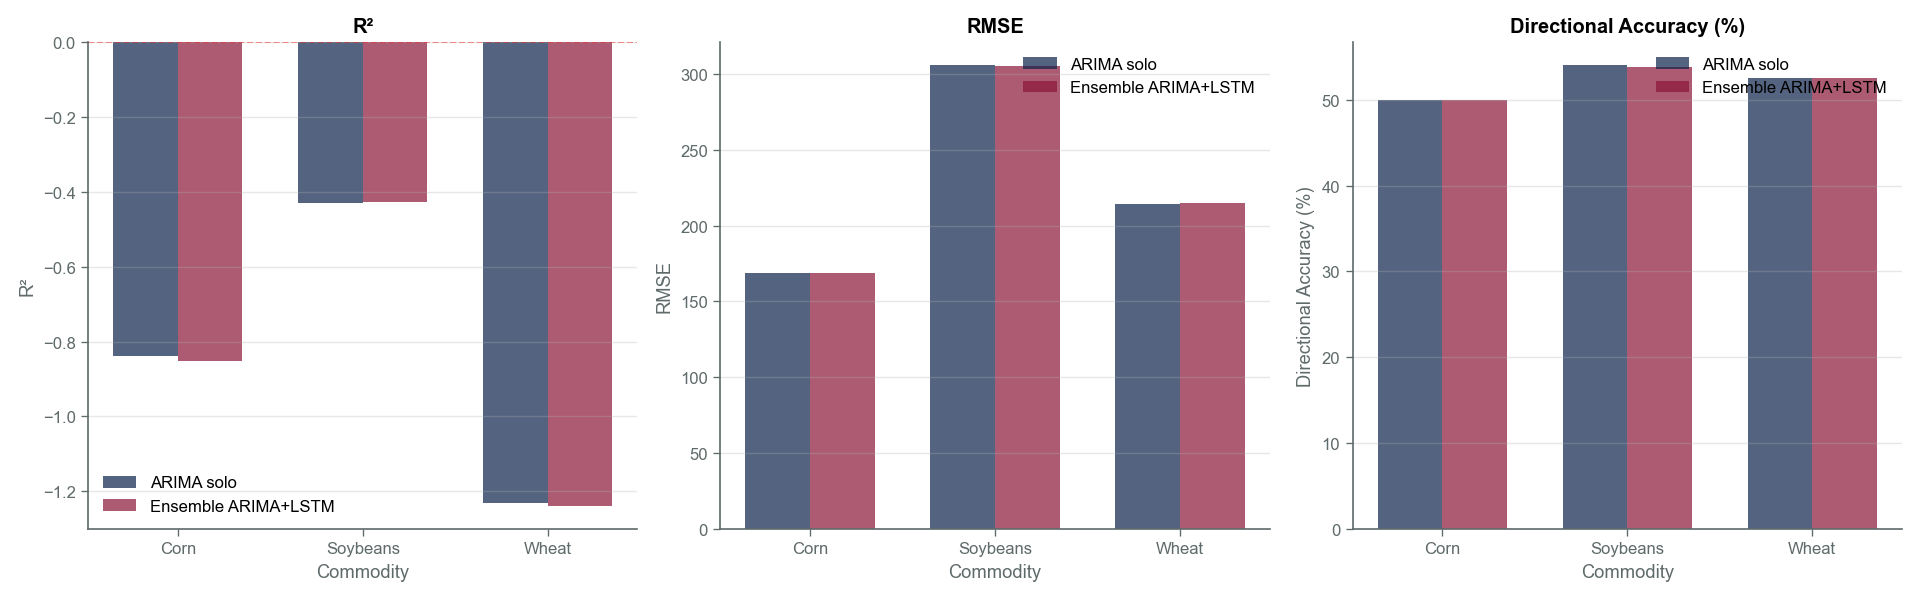

✓ Gráfico guardado: ensemble_arima_lstm_comparison.png


In [34]:
# Bar plot: ARIMA vs Ensemble
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['R²', 'RMSE', 'Directional Accuracy (%)']
metric_cols = [['arima_r2', 'ensemble_r2'], 
               ['arima_rmse', 'ensemble_rmse'], 
               ['arima_da', 'ensemble_da']]

for i, (metric, cols) in enumerate(zip(metrics, metric_cols)):
    ax = axes[i]
    x = np.arange(len(COMMODITIES))
    width = 0.35
    
    arima_vals = results_df[cols[0]].values
    ensemble_vals = results_df[cols[1]].values
    
    ax.bar(x - width/2, arima_vals, width, label='ARIMA solo', alpha=0.7)
    ax.bar(x + width/2, ensemble_vals, width, label='Ensemble ARIMA+LSTM', alpha=0.7)
    
    ax.set_xlabel('Commodity', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in COMMODITIES])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add horizontal line at 0 for R²
    if i == 0:
        ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'figures', 'ensemble_arima_lstm_comparison.png'), 
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: ensemble_arima_lstm_comparison.png")

## 7. Guardar Resultados

In [35]:
# Save results
import json

output = {
    'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'methodology': 'Ensemble ARIMA + LSTM (residuals)',
    'train_test_split': '70-30',
    'lstm_seq_len': seq_len,
    'arima_orders': arima_orders,
    'results': results_df.to_dict(orient='records')
}

with open(os.path.join(PROCESSED_DIR, 'ensemble_arima_lstm_results.json'), 'w') as f:
    json.dump(output, f, indent=2)

results_df.to_csv(os.path.join(PROCESSED_DIR, 'ensemble_arima_lstm_comparison.csv'), index=False)

print("✓ Resultados guardados:")
print(f"  - {os.path.join(PROCESSED_DIR, 'ensemble_arima_lstm_results.json')}")
print(f"  - {os.path.join(PROCESSED_DIR, 'ensemble_arima_lstm_comparison.csv')}")

✓ Resultados guardados:
  - C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\ensemble_arima_lstm_results.json
  - C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\ensemble_arima_lstm_comparison.csv


## 8. Conclusiones

**Hallazgos esperados:**
1. **Si ensemble mejora:** ARIMA captura tendencia lineal, LSTM captura no-linealidades → complementariedad
2. **Si ensemble NO mejora:** Los residuos de ARIMA son ruido blanco (no predecibles) o las 44 features no aportan información adicional
3. **Si ARIMA solo falla:** Series no siguen patrones ARIMA tradicionales (posible por volatilidad de commodities)

**Siguiente paso:** Comparar con LSTM multivariado solo (notebook 3.7) y LSTM walk-forward (notebook 3.10) para determinar modelo óptimo.